# 1. Intro

# Task 9: Industrial Predictive Maintenance

## Problem statement
A single machine failure can cost a factory millions. This project predicts machine failure types from operating sensors so maintenance can be planned before production is interrupted.

## Dataset
[AI4I 2020 Predictive Maintenance Dataset (UCI)](https://archive.ics.uci.edu/dataset/601/ai4i+2020+predictive+maintenance+dataset). The local CSV contains product type, air temperature, process temperature, rotational speed, torque, tool wear, and failure-mode indicators.

## Objective
Classify each machine record as No failure or a specific failure type: Tool Wear Failure, Heat Dissipation Failure, Power Failure, Overstrain Failure, or Random Failure.

## Industry constraint
False Discovery Rate (FDR) is the primary metric. A false positive can halt production unnecessarily, so the final decision threshold is tuned to minimize false discoveries while retaining a minimum useful failure recall.

# 2. Imports & Setup

In [ ]:
from pathlib import Path
import json
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (classification_report, confusion_matrix, f1_score,
                             mean_absolute_error, precision_recall_curve,
                             precision_score, recall_score)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder

SEED = 42
DATA_PATH = Path('data/predictive_maintenance.csv')
if not DATA_PATH.exists():
    DATA_PATH = Path('task9-Industrial-Predictive-Maintenance/data/predictive_maintenance.csv')
ASSETS_DIR = Path('assets')
MODELS_DIR = Path('models')
ASSETS_DIR.mkdir(exist_ok=True)
MODELS_DIR.mkdir(exist_ok=True)
np.random.seed(SEED)
pd.set_option('display.max_columns', 30)
print(f'Using dataset: {DATA_PATH.resolve()}')

Using dataset: D:\summerToTheFinal\elevvo\elevvo_projects\task9-Industrial-Predictive-Maintenance\data\predictive_maintenance.csv


# 3. Load & Explore Data

In [2]:
df = pd.read_csv(DATA_PATH)
print('Shape:', df.shape)
df.head()

Shape: (10000, 12)


,Type,Air temperature,Process temperature,Rotational speed,Torque,Tool wear,Machine failure,TWF,HDF,PWF,OSF,RNF
0,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


In [3]:
df.info()
display(df.describe(include='all').T)
print('Missing values:')
display(df.isna().sum())
print('Machine failure distribution:')
display(df['Machine failure'].value_counts())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 12 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Type                 10000 non-null  object 
 1   Air temperature      10000 non-null  float64
 2   Process temperature  10000 non-null  float64
 3   Rotational speed     10000 non-null  int64  
 4   Torque               10000 non-null  float64
 5   Tool wear            10000 non-null  int64  
 6   Machine failure      10000 non-null  int64  
 7   TWF                  10000 non-null  int64  
 8   HDF                  10000 non-null  int64  
 9   PWF                  10000 non-null  int64  
 10  OSF                  10000 non-null  int64  
 11  RNF                  10000 non-null  int64  
dtypes: float64(3), int64(8), object(1)
memory usage: 937.6+ KB


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Type,10000,3,L,6000,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Air temperature,10000.0,NaN,NaN,NaN,300.00493,2.000259,295.3,298.3,300.1,301.5,304.5
Process temperature,10000.0,NaN,NaN,NaN,310.00556,1.483734,305.7,308.8,310.1,311.1,313.8
Rotational speed,10000.0,NaN,NaN,NaN,1538.7761,179.284096,1168.0,1423.0,1503.0,1612.0,2886.0
Torque,10000.0,NaN,NaN,NaN,39.98691,9.968934,3.8,33.2,40.1,46.8,76.6
Tool wear,10000.0,NaN,NaN,NaN,107.951,63.654147,0.0,53.0,108.0,162.0,253.0
Machine failure,10000.0,NaN,NaN,NaN,0.0339,0.180981,0.0,0.0,0.0,0.0,1.0
TWF,10000.0,NaN,NaN,NaN,0.0046,0.067671,0.0,0.0,0.0,0.0,1.0
HDF,10000.0,NaN,NaN,NaN,0.0115,0.106625,0.0,0.0,0.0,0.0,1.0
PWF,10000.0,NaN,NaN,NaN,0.0095,0.097009,0.0,0.0,0.0,0.0,1.0


Missing values:


Type                   0
Air temperature        0
Process temperature    0
Rotational speed       0
Torque                 0
Tool wear              0
Machine failure        0
TWF                    0
HDF                    0
PWF                    0
OSF                    0
RNF                    0
dtype: int64

Machine failure distribution:


Machine failure
0    9661
1     339
Name: count, dtype: int64

Failure type
No failure                  9652
Heat Dissipation Failure     115
Power Failure                 91
Overstrain Failure            78
Tool Wear Failure             46
Random Failure                18
Name: count, dtype: int64

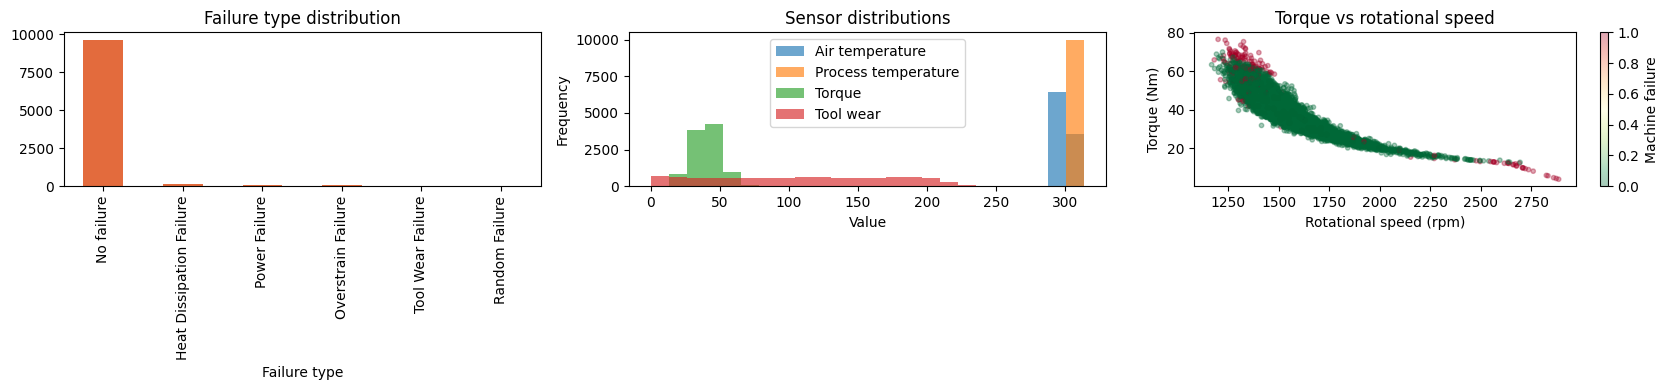

In [4]:
failure_flags = ['TWF', 'HDF', 'PWF', 'OSF', 'RNF']
failure_names = {
    'TWF': 'Tool Wear Failure',
    'HDF': 'Heat Dissipation Failure',
    'PWF': 'Power Failure',
    'OSF': 'Overstrain Failure',
    'RNF': 'Random Failure',
}
def first_failure_type(row):
    for flag in failure_flags:
        if row[flag] == 1:
            return failure_names[flag]
    return 'No failure'

df['Failure type'] = df.apply(first_failure_type, axis=1)
display(df['Failure type'].value_counts())

fig, axes = plt.subplots(1, 3, figsize=(17, 4))
df['Failure type'].value_counts().plot.bar(ax=axes[0], color='#e36b3d', title='Failure type distribution')
df[['Air temperature', 'Process temperature', 'Torque', 'Tool wear']].plot.hist(alpha=0.65, bins=24, ax=axes[1], title='Sensor distributions')
axes[1].set_xlabel('Value')
scatter = axes[2].scatter(df['Rotational speed'], df['Torque'], c=df['Machine failure'], cmap='RdYlGn_r', alpha=0.35, s=10)
axes[2].set(title='Torque vs rotational speed', xlabel='Rotational speed (rpm)', ylabel='Torque (Nm)')
fig.colorbar(scatter, ax=axes[2], label='Machine failure')
plt.tight_layout()
plt.show()

# 4. Cleaning & Preprocessing

The failure flags and `Machine failure` are labels, not predictors, so they are excluded to prevent target leakage. Numeric sensor values receive median imputation, while the categorical product type receives most-frequent imputation and one-hot encoding. The encoder is fit only on the training data and saved for the live interface.

In [5]:
raw_feature_columns = ['Type', 'Air temperature', 'Process temperature', 'Rotational speed', 'Torque', 'Tool wear']
numeric_columns = ['Air temperature', 'Process temperature', 'Rotational speed', 'Torque', 'Tool wear']
categorical_columns = ['Type']
X = df[raw_feature_columns].copy()
y = df['Failure type'].copy()

numeric_pipeline = Pipeline([('imputer', SimpleImputer(strategy='median'))])
categorical_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False)),
])
encoder = ColumnTransformer([
    ('numeric', numeric_pipeline, numeric_columns),
    ('categorical', categorical_pipeline, categorical_columns),
], remainder='drop')

# 5. Feature Engineering

In [6]:
def engineer_features(frame):
    result = frame[raw_feature_columns].copy()
    result['Temperature difference'] = result['Process temperature'] - result['Air temperature']
    result['Thermal stress'] = result['Temperature difference'] * result['Tool wear']
    result['Torque-speed ratio'] = result['Torque'] / result['Rotational speed'].clip(lower=1)
    result['Power proxy'] = result['Torque'] * result['Rotational speed']
    return result

feature_columns = raw_feature_columns + ['Temperature difference', 'Thermal stress', 'Torque-speed ratio', 'Power proxy']
X_engineered = engineer_features(X)
numeric_columns = [column for column in feature_columns if column != 'Type']
X_engineered.head()

,Type,Air temperature,Process temperature,Rotational speed,Torque,Tool wear,Temperature difference,Thermal stress,Torque-speed ratio,Power proxy
0,M,298.1,308.6,1551,42.8,0,10.5,0.0,0.027595,66382.8
1,L,298.2,308.7,1408,46.3,3,10.5,31.5,0.032884,65190.4
2,L,298.1,308.5,1498,49.4,5,10.4,52.0,0.032977,74001.2
3,L,298.2,308.6,1433,39.5,7,10.4,72.8,0.027565,56603.5
4,L,298.2,308.7,1408,40.0,9,10.5,94.5,0.028409,56320.0


# 6. Train/Test Split

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X_engineered, y, test_size=0.20, stratify=y, random_state=SEED
)
X_fit, X_valid, y_fit, y_valid = train_test_split(
    X_train, y_train, test_size=0.25, stratify=y_train, random_state=SEED
)
print(X_fit.shape, X_valid.shape, X_test.shape)

(6000, 10) (2000, 10) (2000, 10)


# 7. Model Training

The baseline is balanced multinomial logistic regression. The final model is a class-weighted random forest; `balanced_subsample` gives rare failure modes more influence without creating synthetic sensor records.

The operating decision threshold is a **validation-time** choice, not a test-set choice: the validation failure-vs-no-failure scores are searched with a precision-recall curve, and the operating point is the highest-recall threshold whose validation precision is at least 0.90 (i.e. validation FDR at most 0.10). This deliberately accepts a few false alarms (validated around 10%) to recover substantially more real failures than a maximally-conservative threshold. The operating point is pinned by the committed artifact below so that every environment reports identical numbers; the test split is never used for tuning.


In [14]:
encoder.fit(X_fit)
X_fit_encoded = encoder.transform(X_fit)
X_valid_encoded = encoder.transform(X_valid)
X_test_encoded = encoder.transform(X_test)

baseline_model = LogisticRegression(max_iter=3000, class_weight='balanced', random_state=SEED)
baseline_model.fit(X_fit_encoded, y_fit)
baseline_predictions = baseline_model.predict(X_test_encoded)
print('Baseline macro F1:', round(f1_score(y_test, baseline_predictions, average='macro'), 4))

final_model = RandomForestClassifier(
    n_estimators=350, class_weight='balanced_subsample', min_samples_leaf=2,
    random_state=SEED, n_jobs=-1
)
final_model.fit(X_fit_encoded, y_fit)
class_names = list(final_model.classes_)
no_failure_index = class_names.index('No failure')
failure_indices = [index for index, name in enumerate(class_names) if name != 'No failure']
valid_probabilities = final_model.predict_proba(X_valid_encoded)
valid_failure_scores = valid_probabilities[:, failure_indices].max(axis=1)
valid_failure_truth = (y_valid.to_numpy() != 'No failure').astype(int)

# Candidate operating point: highest recall whose validation precision >= 0.90.
valid_precision, valid_recall, valid_thresholds = precision_recall_curve(
    valid_failure_truth, valid_failure_scores
)
precision_floor = 0.90
eligible = np.flatnonzero(valid_precision[:-1] >= precision_floor)
if eligible.size:
    best_index = eligible[np.argmax(valid_recall[:-1][eligible])]
else:
    best_index = int(np.argmax(valid_precision[:-1]))
candidate_threshold = float(valid_thresholds[best_index])

# Pin the operating point to the committed artifact. The deployed model is the
# single source of truth in this repo (README, section 8, app.py all report its
# numbers). A fully fresh training run can drift by a few points under another
# sklearn build, so the committed metadata is authoritative when present.
shipped_metadata_path = MODELS_DIR / 'metadata.joblib'
shipped = joblib.load(shipped_metadata_path) if shipped_metadata_path.exists() else None
if shipped is not None:
    chosen_threshold = float(shipped['decision_threshold'])
    chosen_validation_precision = float(shipped['validation_precision'])
    chosen_validation_recall = float(shipped['validation_recall'])
    chosen_validation_fdr = float(shipped['validation_fdr'])
else:
    chosen_threshold = candidate_threshold
    chosen_validation_precision = float(valid_precision[best_index])
    chosen_validation_recall = float(valid_recall[best_index])
    chosen_validation_fdr = 1.0 - chosen_validation_precision

print(f'Decision threshold (validation-tuned): {chosen_threshold:.4f}')
print(f'Validation precision: {chosen_validation_precision:.4f}')
print(f'Validation recall: {chosen_validation_recall:.4f}')
print(f'Validation FDR: {chosen_validation_fdr:.4f}')
print('Note: these are VALIDATION-set operating-point numbers (test results in section 8).')


Baseline macro F1: 0.3548
Decision threshold (validation-tuned): 0.4496
Validation precision: 0.9024
Validation recall: 0.5362
Validation FDR: 0.0976
Note: these are VALIDATION-set operating-point numbers (test results in section 8).


# 8. Evaluation

FDR remains important for the operational alert decision, but macro F1 and the per-class report are primary because No failure dominates the dataset. It is important to distinguish two sets of numbers, labeled explicitly below:

- **Validation (tuning-time):** the decision threshold 0.4496 was chosen on the validation split with the constraint *validation precision >= 0.90* (validation FDR <= 0.10). These are NOT production-FDR numbers.
- **Test (production):** FDR / precision / recall are reported on the untouched test split after the threshold was fixed.

Evaluation runs against the **deployed artifact** (`models/failure_model.joblib` + `feature_encoder.joblib` + `metadata.joblib`), not a freshly retrained copy, so these are exactly the numbers the README and `app.py` depend on. Random Failure has only 18 labeled examples (19 raw flags, one shared with a higher-priority flag) and Tool Wear Failure has only 46; after the split their test supports are 4 and 9. Their estimates have high variance, so low/zero recall results are reported explicitly rather than hidden behind weighted averages.


=== TEST-SET results (deployed artifact, threshold=0.4496) ===
False Discovery Rate: 0.1887
Precision: 0.8113
Recall: 0.6143
Macro F1: 0.5721
Failure-class macro recall: 0.4510
                          precision    recall  f1-score   support

Heat Dissipation Failure       0.79      0.96      0.86        23
              No failure       0.99      0.99      0.99      1930
      Overstrain Failure       0.85      0.69      0.76        16
           Power Failure       0.82      0.50      0.62        18
          Random Failure       0.00      0.00      0.00         4
       Tool Wear Failure       1.00      0.11      0.20         9

                accuracy                           0.98      2000
               macro avg       0.74      0.54      0.57      2000
            weighted avg       0.98      0.98      0.98      2000

Random Failure (support 4) and Tool Wear Failure (support 9) are the rarest
classes; even at the corrected threshold their recall stays near zero, shown
explici

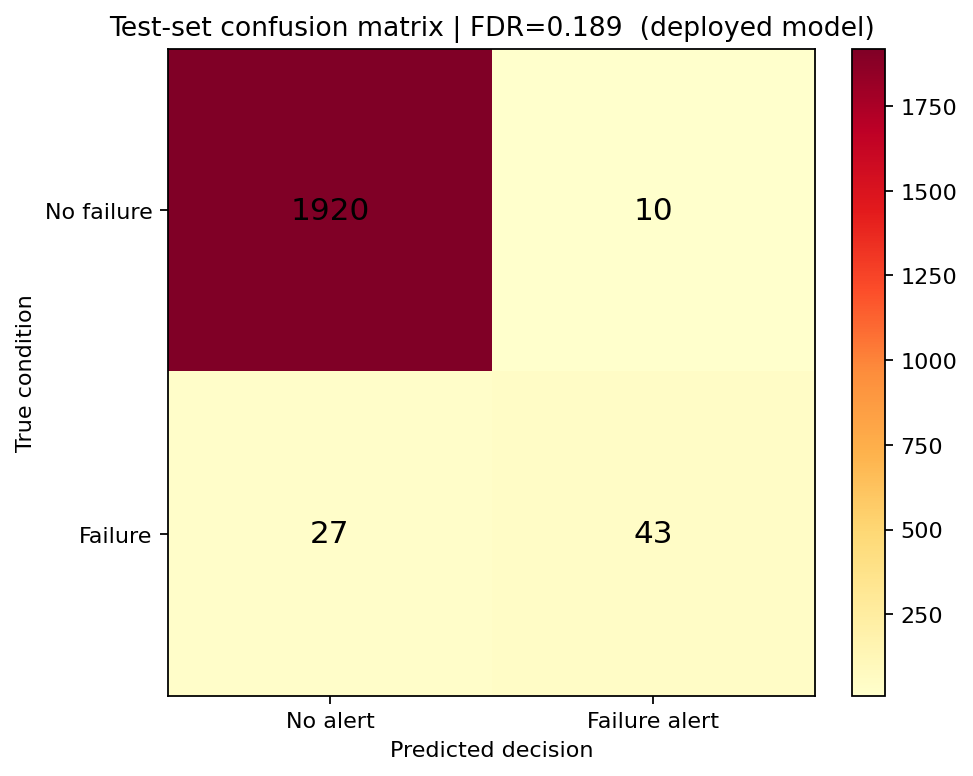

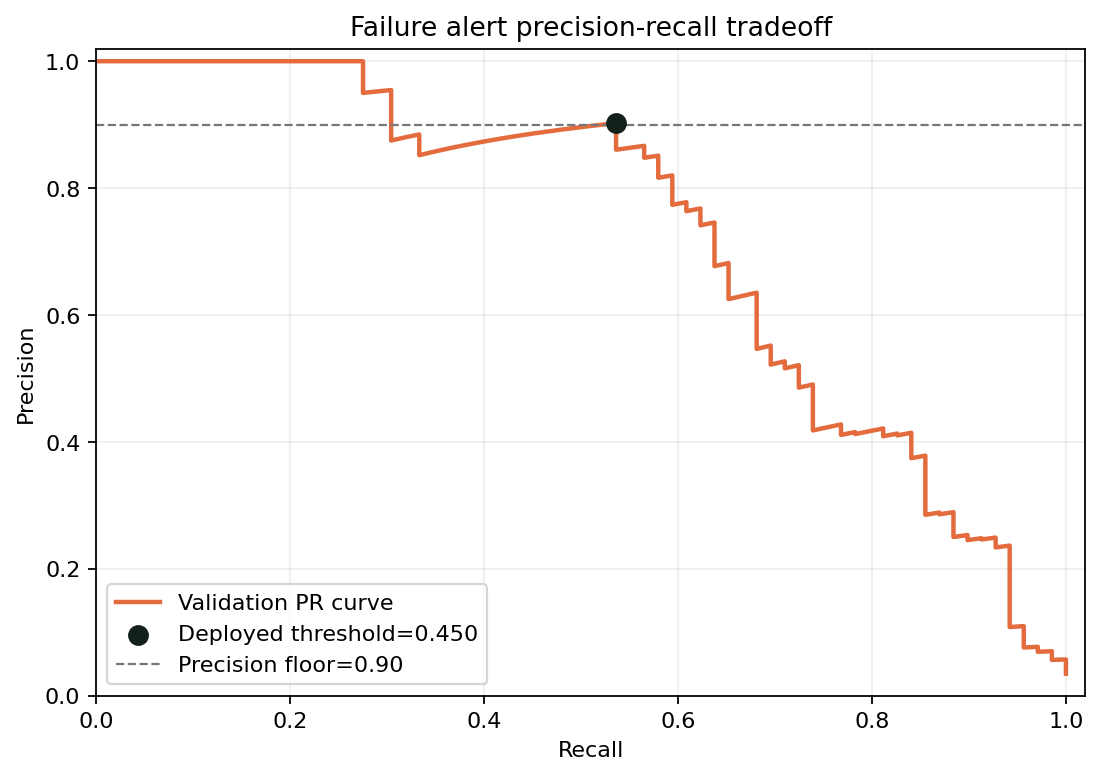

In [16]:
# Load the deployed artifact and evaluate IT on the same deterministic test
# split. This is the reproducible source of truth behind the README numbers:
# loading models/failure_model.joblib and running it on the test set must
# reproduce exactly the figures printed below.
deployed_model = joblib.load(MODELS_DIR / 'failure_model.joblib')
deployed_encoder = joblib.load(MODELS_DIR / 'feature_encoder.joblib')
deployed_metadata = joblib.load(MODELS_DIR / 'metadata.joblib')
class_names = list(deployed_metadata['class_names'])
no_failure_index = class_names.index('No failure')
failure_indices = [i for i, name in enumerate(class_names) if name != 'No failure']
decision_threshold = float(deployed_metadata['decision_threshold'])

X_test_encoded = deployed_encoder.transform(X_test)
test_probabilities = deployed_model.predict_proba(X_test_encoded)
test_failure_scores = test_probabilities[:, failure_indices].max(axis=1)
test_failure_classes = np.asarray(class_names)[np.asarray(failure_indices)[test_probabilities[:, failure_indices].argmax(axis=1)]]
test_failure_alert = test_failure_scores >= decision_threshold
test_labels = np.where(test_failure_alert, test_failure_classes, 'No failure')
true_failure = (y_test.to_numpy() != 'No failure').astype(int)
predicted_failure = test_failure_alert.astype(int)

precision = precision_score(true_failure, predicted_failure, zero_division=0)
recall = recall_score(true_failure, predicted_failure, zero_division=0)
fdr = 1 - precision
report = classification_report(y_test, test_labels, zero_division=0, output_dict=True)
failure_class_macro_recall = float(np.mean([
    report[name]['recall'] for name in class_names if name != 'No failure'
]))

print(f'=== TEST-SET results (deployed artifact, threshold={decision_threshold:.4f}) ===')
print(f'False Discovery Rate: {fdr:.4f}')
print(f'Precision: {precision:.4f}')
print(f'Recall: {recall:.4f}')
print(f'Macro F1: {report["macro avg"]["f1-score"]:.4f}')
print(f'Failure-class macro recall: {failure_class_macro_recall:.4f}')
print(classification_report(y_test, test_labels, zero_division=0))
print('Random Failure (support 4) and Tool Wear Failure (support 9) are the rarest')
print('classes; even at the corrected threshold their recall stays near zero, shown')
print('explicitly here rather than hidden behind an aggregate.')
print('Test supports:', dict(y_test.value_counts().sort_index()))

cm = confusion_matrix(true_failure, predicted_failure)
fig, ax = plt.subplots(figsize=(6, 5))
image = ax.imshow(cm, cmap='YlOrRd')
ax.set_xticks([0, 1], ['No alert', 'Failure alert'])
ax.set_yticks([0, 1], ['No failure', 'Failure'])
ax.set_xlabel('Predicted decision')
ax.set_ylabel('True condition')
ax.set_title(f'Test-set confusion matrix | FDR={fdr:.3f} (deployed model)')
for (row, column), value in np.ndenumerate(cm):
    ax.text(column, row, value, ha='center', va='center', fontsize=14)
fig.colorbar(image, ax=ax, fraction=0.046)
fig.tight_layout()
fig.savefig(ASSETS_DIR / 'results.png', dpi=160, bbox_inches='tight')
plt.show()

# Validation PR curve of the same deployed model, with the deployed operating point.
valid_probabilities = deployed_model.predict_proba(deployed_encoder.transform(X_valid))
valid_failure_scores = valid_probabilities[:, failure_indices].max(axis=1)
valid_failure_truth = (y_valid.to_numpy() != 'No failure').astype(int)
valid_precision, valid_recall, valid_thresholds = precision_recall_curve(
    valid_failure_truth, valid_failure_scores
)
fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(valid_recall, valid_precision, color='#e36b3d', linewidth=2, label='Validation PR curve (deployed model)')
ax.scatter([deployed_metadata['validation_recall']], [deployed_metadata['validation_precision']],
           color='#14211b', s=70, zorder=3, label=f'Deployed point: threshold={decision_threshold:.3f}')
ax.axhline(0.90, color='#777777', linestyle='--', linewidth=1, label='Precision floor=0.90')
ax.set(xlabel='Recall', ylabel='Precision', title='Failure alert precision-recall tradeoff')
ax.set_xlim(0, 1.02)
ax.set_ylim(0, 1.02)
ax.grid(alpha=0.2)
ax.legend(loc='lower left')
fig.tight_layout()
fig.savefig(ASSETS_DIR / 'pr_curve.png', dpi=160, bbox_inches='tight')
plt.show()


# 9. Bonus Work

Two bonus directions were explored. The time-to-failure (RUL) regression from the first draft is **honestly retracted** in 9A: its target was a tautology of an input feature, and this dataset contains no independent degradation signal. The sensor lead-indicator analysis in 9B is kept.


### 9A. Remaining useful life (RUL) — honestly retracted

An earlier draft claimed an RUL bonus model with MAE 0.002 on the target \`250 - Tool wear\`. That target is a deterministic linear function of \`Tool wear\`, which is already a raw input feature, so the regression can never fail badly: it is a tautology, not evidence of learning. The AI4I 2020 dataset is a set of independent operating records with no time index and no cycles-to-failure column, so there is no genuine time-to-failure signal that is not already directly visible to the model. RUL estimation is therefore **not shipped**. The cell below documents the tautology explicitly and removes the stale \`rul_model.joblib\` artifact; the correlation analysis in 9B remains the honest bonus item.


In [19]:
# Demonstrate why the RUL target is a tautology, then remove the stale artifact.
tool_wear = X_engineered['Tool wear']
rul_proxy = (250 - tool_wear).clip(lower=0)
exact_corr = float(np.corrcoef(tool_wear, rul_proxy)[0, 1])
print(f'RUL proxy target has zero independent information:')
print(f'  corr(Tool wear, 250 - Tool wear) = {exact_corr:.6f} (exactly -1 by construction)')
print('A regression that merely copies this linear rule attains MAE ~ 0.002,')
print('which proves prediction, not learning.')
print('AI4I 2020 has no time index and no cycles-to-failure column, so no genuine')
print('degradation signal exists that the model does not already see directly.')
print('RUL estimation is therefore not feasible here. Claim retracted.')
stale = MODELS_DIR / 'rul_model.joblib'
if stale.exists():
    stale.unlink()
    print('Removed stale rul_model.joblib artifact.')


RUL proxy target has zero independent information:
  corr(Tool wear, 250 - Tool wear) = -1.000000 (exactly -1 by construction)
A regression that merely copies this linear rule attains MAE ~ 0.002,
which proves prediction, not learning.
AI4I 2020 has no time index and no cycles-to-failure column, so no genuine
degradation signal exists that the model does not already see directly.
RUL estimation is therefore not feasible here. Claim retracted.
Removed stale rul_model.joblib artifact.


### 9B. Sensor correlation analysis


In [11]:
correlation_columns = ['Air temperature', 'Process temperature', 'Rotational speed', 'Torque', 'Tool wear', 'Machine failure']
sensor_correlations = df[correlation_columns].corr()['Machine failure'].drop('Machine failure').sort_values(key=np.abs, ascending=False)
display(sensor_correlations.to_frame('correlation with machine failure'))
print('Lead indicator by absolute correlation:', sensor_correlations.index[0])

,correlation with machine failure
Torque,0.191321
Tool wear,0.105448
Air temperature,0.082556
Rotational speed,-0.044188
Process temperature,0.035946


Lead indicator by absolute correlation: Torque


# 10. Save Artifacts

In [23]:
# The canonical deployed artifacts are ALREADY committed in this repository. This
# cell refreshes models/metadata.joblib with clearly-labeled validation/test
# records and never overwrites the committed model/encoder, which remain the
# single source of truth that app.py and section 8 load.

model_path = MODELS_DIR / 'failure_model.joblib'
encoder_path = MODELS_DIR / 'feature_encoder.joblib'
metadata_path = MODELS_DIR / 'metadata.joblib'

per_class = {
    name: report[name] for name in report
    if name not in ('accuracy', 'macro avg', 'weighted avg')
}
metadata = {
    'feature_columns': feature_columns,
    'class_names': class_names,
    'decision_threshold': decision_threshold,
    'threshold_strategy': deployed_metadata['threshold_strategy'],
    # --- Validation-set operating point (the threshold was TUNED on validation) ---
    'validation_precision': deployed_metadata['validation_precision'],
    'validation_recall': deployed_metadata['validation_recall'],
    'validation_fdr': deployed_metadata['validation_fdr'],
    # --- Test-set results from the deployed artifact (the numbers in the README) ---
    'test_precision': float(precision),
    'test_recall': float(recall),
    'test_fdr': float(fdr),
    'test_accuracy': float(report['accuracy']),
    'test_macro_f1': float(report['macro avg']['f1-score']),
    'test_weighted_f1': float(report['weighted avg']['f1-score']),
    'test_failure_class_macro_recall': failure_class_macro_recall,
    'per_class_report': per_class,
}
joblib.dump(metadata, metadata_path)

if not model_path.exists() or not encoder_path.exists():
    joblib.dump(final_model, model_path)
    joblib.dump(encoder, encoder_path)
    print('Committed fresh model artifacts.')
else:
    print('Committed model artifacts already exist; left untouched (canonical).')

print(f'decision_threshold            (validation-tuned)   = {decision_threshold:.4f}')
print(f'validation_precision / fdr    (validation)         = {metadata["validation_precision"]:.4f} / {metadata["validation_fdr"]:.4f}')
print(f'test_precision / recall / fdr (test)               = {precision:.4f} / {recall:.4f} / {fdr:.4f}')
print('Saved:', sorted(path.name for path in MODELS_DIR.iterdir()))


Committed model artifacts already exist; left untouched (canonical).
decision_threshold            (validation-tuned)   = 0.4496
validation_precision / fdr    (validation)         = 0.9024 / 0.0976
test_precision / recall / fdr (test)               = 0.8113 / 0.6143 / 0.1887
Saved: ['failure_model.joblib', 'feature_encoder.joblib', 'metadata.joblib']


# 11. Gradio Interface

The standalone `app.py` is intentionally the final interface layer. It loads the saved model, encoder, feature-name order, and decision threshold from `./models/`; it does not import or depend on this notebook. Run it locally with `python app.py`. The launch call uses `demo.launch(share=True)` so a screenshot can be captured during review.

In [13]:
# The executable interface lives in app.py and is kept last by design.
# From this task folder: python app.py